In [1]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
IMAGE_DIR = "../images/train"
CSV_PATH = "../data/raw/train.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
df = pd.read_csv(CSV_PATH)

df["log_price"] = np.log1p(df["price"])


In [4]:
df["image_id"] = df.index

def has_image(image_id):
    return os.path.exists(os.path.join(IMAGE_DIR, f"{image_id}.png"))

df_valid = df[df["image_id"].apply(has_image)].copy()

print("Valid samples:", len(df_valid))

df_valid = df_valid.reset_index(drop=True)

Valid samples: 16201


In [5]:
train_df, val_df = train_test_split(
    df_valid,
    test_size=0.2,
    random_state=42
)

In [6]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class ImageOnlyDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.iloc[idx]["image_id"]
        img_path = os.path.join(self.image_dir, f"{image_id}.png")

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        y = torch.tensor(
            self.df.iloc[idx]["log_price"],
            dtype=torch.float32
        )

        return image, y


In [8]:
train_dataset = ImageOnlyDataset(train_df, IMAGE_DIR, image_transform)
val_dataset = ImageOnlyDataset(val_df, IMAGE_DIR, image_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [9]:
model = models.resnet18(pretrained=True)

# Freeze convolutional layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head
model.fc = nn.Linear(512, 1)

model = model.to(device)


C:\Users\keshav bansal\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\keshav bansal\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)


In [11]:
def train_one_epoch(model, loader):
    model.train()
    losses = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        preds = model(images).squeeze(1)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)


In [12]:
def evaluate(model, loader):
    model.eval()
    preds_all, targets_all = [], []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            preds = model(images).squeeze(1)

            preds_all.append(preds.cpu().numpy())
            targets_all.append(targets.cpu().numpy())

    preds_all = np.concatenate(preds_all)
    targets_all = np.concatenate(targets_all)

    rmse = np.sqrt(mean_squared_error(targets_all, preds_all))
    r2 = r2_score(targets_all, preds_all)

    return rmse, r2


In [13]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_rmse, val_r2 = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R2: {val_r2:.4f}"
    )


Epoch 1 | Train Loss: 6.9740 | Val RMSE: 1.4691 | Val R2: -6.9229
Epoch 2 | Train Loss: 1.6779 | Val RMSE: 1.2696 | Val R2: -4.9168
Epoch 3 | Train Loss: 1.3277 | Val RMSE: 1.1629 | Val R2: -3.9643
Epoch 4 | Train Loss: 1.1345 | Val RMSE: 1.1016 | Val R2: -3.4549
Epoch 5 | Train Loss: 0.9979 | Val RMSE: 1.0131 | Val R2: -2.7674
Epoch 6 | Train Loss: 0.9145 | Val RMSE: 0.9721 | Val R2: -2.4686
Epoch 7 | Train Loss: 0.8566 | Val RMSE: 0.9372 | Val R2: -2.2239
Epoch 8 | Train Loss: 0.8229 | Val RMSE: 0.9307 | Val R2: -2.1794
Epoch 9 | Train Loss: 0.7794 | Val RMSE: 0.9060 | Val R2: -2.0129
Epoch 10 | Train Loss: 0.7700 | Val RMSE: 0.8824 | Val R2: -1.8584


In [30]:
import cv2
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image_tensor):
        self.model.eval()

        output = self.model(image_tensor)
        output.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = cam[0].detach().cpu().numpy()
        cam = cv2.resize(cam, (256, 256))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam


In [31]:
gradcam = GradCAM(
    model,
    target_layer=model.layer4
)


In [61]:
model.eval()

image, y = val_dataset[0] 
image_tensor = image.unsqueeze(0).to(device)
image_tensor.requires_grad_()


tensor([[[[-0.0801, -0.0629,  0.0227,  ..., -0.2171, -0.0801, -0.0116],
          [-0.0972, -0.0801,  0.0398,  ..., -0.2513, -0.1314, -0.0629],
          [ 0.1597, -0.0116, -0.0801,  ..., -0.2513, -0.1486, -0.0801],
          ...,
          [-0.4226, -0.3369, -0.2171,  ..., -0.8507, -0.9363, -0.9020],
          [-0.3541, -0.2856, -0.1828,  ..., -0.7137, -0.6452, -0.5596],
          [-0.1828, -0.2342, -0.3198,  ..., -0.5082, -0.4568, -0.4054]],

         [[ 0.1527,  0.1702,  0.2402,  ...,  0.2052,  0.2752,  0.3277],
          [ 0.1527,  0.1527,  0.2577,  ...,  0.1702,  0.2227,  0.2752],
          [ 0.4503,  0.2752,  0.1877,  ...,  0.1527,  0.2052,  0.2577],
          ...,
          [-0.3901, -0.2675, -0.1625,  ..., -0.1450, -0.2150, -0.1625],
          [-0.3725, -0.2500, -0.1275,  ...,  0.0126,  0.0826,  0.1877],
          [-0.1975, -0.2150, -0.2675,  ...,  0.2227,  0.2927,  0.3452]],

         [[-0.0790, -0.0441,  0.0605,  ..., -0.0267,  0.0953,  0.1651],
          [-0.0964, -0.0615,  

In [62]:
cam = gradcam.generate(image_tensor)
print(cam.shape)  # usually (7,7) or (14,14)


(256, 256)


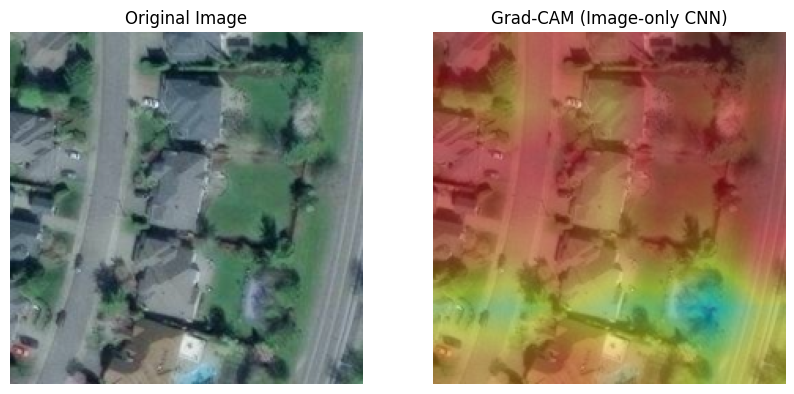

In [63]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Original image (unnormalize if needed)
orig = image.permute(1,2,0).cpu().numpy()
orig = (orig - orig.min()) / (orig.max() - orig.min())

# Resize CAM to image size
cam_resized = cv2.resize(cam, (orig.shape[1], orig.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = heatmap / 255.0

overlay = 0.6 * orig + 0.4 * heatmap

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Grad-CAM (Image-only CNN)")
plt.axis("off")

plt.show()
